# CSCI 3352 Biological Networks, Prof. Clauset
Submit here: https://canvas.colorado.edu/courses/101449

# Problem Set 5 : Predicting missing links in networks

***

**Name**: Dominic Galgano

***

This assignment is due on Canvas by **11:55pm on Friday, February 23**. Your solutions to non-programming questions should be done in Markdown directly below the associated question. Your solutions to computational questions should include any specified Python code and results as well as written commentary on your conclusions.  Remember that you are encouraged to discuss the problems with your classmates, but **you must write all code and solutions on your own** (see syllabus for detailed guidance). There are 102 points total, and 37 pts extra credit.

**NOTES**: 

- Unless a url is given for a data set, you will find the required data on the course Canvas.
- If you're not familiar with typesetting math directly in Markdown, you may do your work on paper first and then typeset it later. This [reference guide](https://math.meta.stackexchange.com/questions/5020/mathjax-basic-tutorial-and-quick-reference) provides helpful guidance for writing math in Markdown. 
- It is **unhelpful** to make your reader interpret numerical output from your code.  If a question asks you to compute some value from the data you should show your code output **AND** write a summary of the results in Markdown directly below your code.

***
* networkx [Documentation](https://networkx.github.io/documentation/stable/) and [Tutorial](https://networkx.github.io/documentation/stable/tutorial.html)
* igraph [Documentation](https://igraph.org/python/versions/latest/install.html) and [Tutorial](https://igraph.org/python/tutorial/0.9.8/tutorial.html)

In [1]:
import networkx as nx
import numpy as np
import matplotlib
import matplotlib.pylab as plt
%matplotlib inline

***
## Problem 1 : Warm up (10 pts total)

For the network $G_\circ$ given below, calculate by hand and report the `Jaccard coefficient` and `degree product` score values for the following pairs of nodes:
* $i=1$ and $j=4$
* $i=1$ and $j=5$
* $i=4$ and $j=9$
* $i=9$ and $j=2$

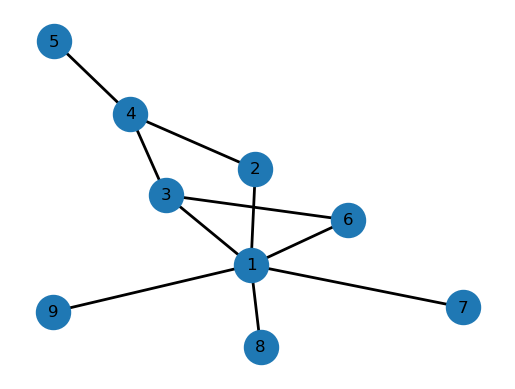

In [2]:
Go = nx.Graph([(1,2),(1,3),(1,6),(1,7),(1,8),(1,9),(3,4),(3,6),(4,5),(4,2)]) # observed graph Go

nx.draw_networkx(Go,with_labels=True,node_size=600,width=2) # draw it pretty
limits=plt.axis('off')                                      # turn off axes
plt.show() 

Assuming the Jaccard coefficient between any two nodes can be found with $J(i, j) = \frac{|V(i) \cup V(j)|}{|V(i) \cap V(j)|}$

| i j  | V(i)                 | V(j)           | Magnitude of V(i) ∩ V(j)| Magnitude of V(i) ∪ V(j)    | Jaccard Coefficient |
| ---- | -------------------- | -------------- | ----------------- | -------------- | ------------------- |
| 1 4  | V(1) = {2,3,6,7,8,9} | V(4) = {2,3,5} |   2               | 9              | 2/9 = 0.2222        |
| 1 5  | V(1) = {2,3,6,7,8,9} | V(5) = {4}     |   0               | 7              | 0/7 = 0             |
| 4 9  | V(4) = {2,3,5}       | V(9) = {1}     |   0               | 4              | 0/4 = 0             |
| 9 2  | V(9) = {1}           | V(2) = {1,4}   |   1               | 2              | 1/2 = 0.5           |

Assuming the Degree product between any two nodes can be found with $dp(i,j) = k_ik_j$
| i j  | Ki | Kj | Degree Product |
| ---- | -- | -- | -------------- |
| 1 4  | 6  | 3  |   18           | 
| 1 5  | 6  | 1  |   6            |
| 4 9  | 3  | 1  |   3            | 
| 9 2  | 1  | 2  |   2            |

***
## Problem 2 : Where did all the links go? (92 pts total)

In this problem, you will implement and systematically evaluate the `baseline`, `Jaccard coefficient` and `degree product` predictors for missing links. As with the missing attribute prediction in PS4, we'll build up this numerical experiment in stages.
* First, you'll implement the `baseline`, `Jaccard coefficient`, and `degree product` score functions.
* Then, you'll construct an ROC curve and compute its AUC using synthetic data.
* After that, you'll construct a *good* test of the 3 link predictors for a single level of _missingness_ $\alpha$. 
* And finally, you'll write a wrapper around this function to explore how performance varies as a function of $\alpha$.

For the last two steps, we'll again use a real-world network derived from the genes of the human malaria parasite _P. falciparum_. These genes are located in one of nine highly variable regions (HVRs) in the DBLa domain of the parasite's var protein. In this network, nodes are antigen *genes* of the parasite and two nodes are connected if they contain evidence of past non-homologous *recombination* (basically, if they share a long subsequence).
* Visit the [Index of Complex Networks](https://icon.colorado.edu/) and obtain the `HVR_1` network via the ICON entry _Malaria var DBLa HVR networks_.

### Problem 2-A (12 pts) : baseline, Jaccard, and degree product score functions

* Write 3 seperate functions to implement the `predictor_Baseline()`, `predictor_Jaccard()`, and `predictor_DegreeProd()` score functions, as described in Lecture Notes 4. Function interfaces are given below.
* Then write a function `apply_Predictors(G,Y)`, which applies the three predictors to a given simple network `G` with list of missing links `Y`. This function should
  * first obtain the list of candidate pairs (non-edges in `G`, defined as `X` in the Lecture Notes),
  * for each such pair, apply the 3 predictors, and
  * store the results in a way that allows you to output a table of the form shown in Lecture Notes 4, with columns `i,j,tau,score_baseline,score_Jaccard,score_DegreePred`
* Then,
  * run your function on the $G_\circ$ given below
  * sort the rows of the output table by the `score_Jaccard` column, and 
  * write out the sorted table in the form `{i},{j} : {tau} : {baseline}  {jaccard}  {degree prod}`

Hint 1: `networkx` has two built-in functions that may be useful: `jaccard_coefficient()` and `preferential_attachment()`, but note that you will need to write a wrapper around each in order to make them break ties randomly the way we defined in the lecture notes. Also, be warned: these functions return a 'generator'.

Hint 2a: I found it useful to have `apply_Predictors(G,Y)` return its results as a 2d numpy array, where the first 2 columns are $i,j$, the 3rd column is the $\tau$ value indicating if $i,j$ is a missing edge or not, and the last 3 columns give the baseline, jaccard, and degree product scores in that order. This made it straightforward to then sort the rows by the jaccard score, using the `.argsort()` function. You're free to use whatever data structure you want.

Hint 2b: I also found it useful to implement a helper function `get_candidateEdges(G)` that took as input `G` and returned as output `X`, the list of non-edges in `G`, which my `apply_Predictors(G,Y)` function calls.

In [33]:
def predictor_Baseline():
    # implements the baseline link predictor
    # input : none, because its output is independent of G
    # output: score(i,j) = r where r = Uniform(0,1)
    
    ####################################
    ##### do not modify above here #####

    return rnd.uniform(0,1)


In [64]:
def predictor_Jaccard(Gx,i,j):
    # implements the Jaccard coefficient link predictor
    # input : Gx:  a simple networkx graph
    #       : i,j: node indices i,j in Gx
    # output: score(i,j) = Jaccard(i,j) + Uniform(0,epsilon) for epsilon << 1 (a very small value)

    ####################################
    ##### do not modify above here #####
    
    #Get the list of neighbors once 
    i_neighbors = list(Gx.neighbors(i))
    j_neighbors = list(Gx.neighbors(j))
    
    #Initialize variables
    mag_ij_inter = 0
    mag_ij_union = len(i_neighbors) + len(j_neighbors)
    
    #Find the magnitude of the intersect of i and j's neighbors
    for node in i_neighbors:
        if node in j_neighbors:
            mag_ij_inter = mag_ij_inter + 1
    
    return (mag_ij_inter / mag_ij_union) + rnd.uniform(0,0.1)

In [65]:
def predictor_DegreeProd(Gx,i,j):
    # implements the baseline link predictor
    # input : Gx:  a simple networkx graph
    #       : i,j: node indices i,j in Gx
    # output: score(i,j) = DegreeProduct(i,j) + Uniform(0,epsilon) for epsilon << 1 (a very small value)

    ####################################
    ##### do not modify above here #####
    
    #Get the degrees of nodes i and j
    i_neighbors = len(list(Gx.neighbors(i)))
    j_neighbors = len(list(Gx.neighbors(j)))
    
    return (i_neighbors * j_neighbors) + rnd.uniform(0,0.1)


In [234]:
def apply_Predictors(G,Y):
    # input : G, a networkx simple graph
    #         Y, list of missing links in G
    # output: S, table of the form [ i | j | tau | baseline | jaccard | degree product ]

    ####################################
    ##### do not modify above here #####
    
    #List of all candidate pairs
    X = []
    
    #Attempts to find all candidate pairs by calcuating X = V x V - Eo
    for i in G:
        for j in G:
            if (not G.has_edge(i,j)) and ((j, i) not in X) and (i != j):
                X.append((i, j))
    
    #For each of the observed unconnected node pairs
    table = np.zeros((len(X),6))
    
    cur_row = 0
    for i, j in X:  
        table[cur_row, 0] = i
        table[cur_row, 1] = j
        
        #If i and j are in the missing edge set set Tao to 1
        if (i,j) in Y:
            table[cur_row, 2] = 1
        else:
            table[cur_row, 2] = 0
        
        #Calculate Jaccard predictor
        table[cur_row, 3] = predictor_Baseline()
        #Calculate Jaccard predictor
        table[cur_row, 4] = predictor_Jaccard(G,i,j)
        #Calculate Degree Product predictor
        table[cur_row, 5] = predictor_DegreeProd(G,i,j)
        
        cur_row = cur_row + 1
    
    return table    


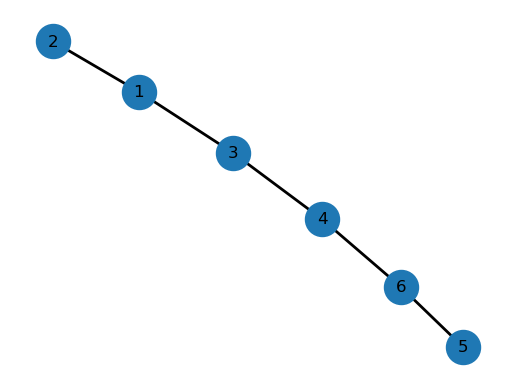

{i},{j} : {tau} : {baseline}  {jaccard}  {degree prod}
[[4.         5.         1.         0.40704772 0.39494977 2.07510405]
 [2.         3.         1.         0.10762904 0.37441962 2.08312144]
 [1.         4.         0.         0.40034659 0.29649385 4.07172821]
 [3.         6.         0.         0.53230888 0.29125533 4.02514591]
 [2.         6.         0.         0.06441631 0.08460699 2.03573797]
 [1.         6.         0.         0.58581256 0.0533751  4.01617719]
 [1.         5.         0.         0.08577782 0.04401858 2.00931823]
 [2.         5.         0.         0.87408251 0.03068058 1.0934725 ]
 [2.         4.         0.         0.77496907 0.01844686 2.04017606]
 [3.         5.         0.         0.87261863 0.01440504 2.00235456]]


In [281]:
Go      = nx.Graph([(1,2),(1,3),(3,4),(5,6),(4,6)]) # observed graph Go, from Lecture 4
missing = [(2,3),(4,5)]                             # list of edges missing from Go

nx.draw_networkx(Go,with_labels=True,node_size=600,width=2) # draw it pretty
limits=plt.axis('off')                                                             # turn off axes
plt.show() 

####################################
##### do not modify above here #####
import random as rnd

predictions = apply_Predictors(Go, missing)

print("{i},{j} : {tau} : {baseline}  {jaccard}  {degree prod}")
print(predictions[predictions[:, 4].argsort()[::-1]])

### Problem 2-B (20 pts) : ROC that curve and AUC

* Write a function `tabulate_TPR_FPR(S)` that extends the basic score table from `Problem 2-A` to include columns for TPR and FPR values, as described in Lecture Notes 4.
* Then write a function `calculate_AUC(TPR,FPR)` that takes as input the TPR and FPR columns of your table, and computes the AUC.
* Finally, for each of the three predictors `baseline`, `Jaccard`, and `degree product`, apply your functions to
  * compute the TPR and FPR values, and use them to plot a ROC curve (include a $y=x$ reference line)
  * *2 pts extra credit* if you plot the three ROC curves on a single plot,
  * compute and report the AUC values for each predictor (be sure to label which is which), and
  * then comment briefly on the ROC curves, AUC values, and which predictor is better for this graph `Go`.

Hint 1: After tabulating the TPR and FPR columns, don't forget to prepend a row for (TPR=0,FPR=0) before you make the ROC plot or compute the AUC.

Hint 2: However you decided to store the table will determine how you write these two functions. In my solutions, `S` is a 2d numpy array.

In [381]:
def tabulate_TPR_FPR(S):
    # see Lecture Notes 4
    # input : a data structure S containing a table whose rows have the form:
    #         [ i j tau score(i,j) ]
    #        sorted in descending order of score(i,j)
    # output: a data structure T containing a table whose rows have the form:
    #         [ i j tau TPR FPR score(i,j) ]
    #        sorted descending in score(i,j)

    ####################################
    ##### do not modify above here #####
    rows, cols = np.shape(S)
    temp = np.array([0]*rows)
    
    tfpr_table = np.insert(S, 3, temp, axis=1)
    tfpr_table = np.insert(tfpr_table, 3, temp, axis=1)
    
    rows, cols = np.shape(tfpr_table)
    T = np.sum(tfpr_table[:, 2])
    F = rows - T
    
    #Calculate TPR(l) and FPR(l)
    Tk = 0
    Fk = 0
    for row in range(rows):
        if tfpr_table[row, 2] == 1:
            Tk = Tk + 1
        else:
            Fk = Fk + 1
        TPR = Tk / T
        tfpr_table[row, 3] = TPR
        
        FPR = Fk / F
        tfpr_table[row, 4] = FPR
        
    #print(tfpr_table)
    
    return tfpr_table


In [382]:
def calculate_AUC(TPR,FPR):
    # see Lecture Notes 4
    # input : the TPR and FPR columns of your table (which have equal length and where TPR[0]=FPR[0]=0)
    # output: the AUC, a scalar on the unit interval

    ####################################
    ##### do not modify above here #####  
    #Initialize return value
    AUC = 0
    #Caluclate AUC
    for row_ind in range(len(TPR)):
        if row_ind > 0:
            AUC = AUC + (TPR[row_ind] * (FPR[row_ind] - FPR[row_ind - 1]))
        else: 
            AUC = AUC + (TPR[row_ind] * FPR[row_ind])
    return AUC


Baseline AUC =  0.3125
Jaccard Coefficient AUC =  1.0
Degree Product AUC =  0.625


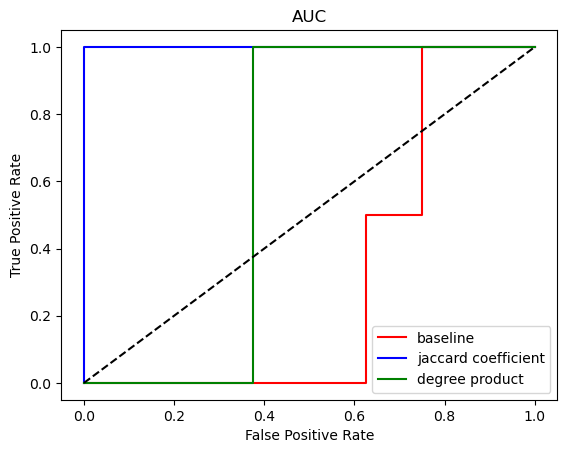

In [390]:
#Takes the score table from above and grabs only elements related to baseline
baseline = predictions[predictions[:, 3].argsort()[::-1]]
baseline = np.delete(baseline, 5, axis=1)
baseline = np.delete(baseline, 4, axis=1)
#print(baseline)
b_tab = tabulate_TPR_FPR(baseline)
print("Baseline AUC = ", calculate_AUC(b_tab[:, 3],b_tab[:, 4]))
#Takes the score table from above and grabs only elements related to Jaccard Coefficient
jaccard = predictions[predictions[:, 4].argsort()[::-1]]
jaccard = np.delete(jaccard, 5, axis=1)
jaccard = np.delete(jaccard, 3, axis=1)
#print(jaccard)
j_tab = tabulate_TPR_FPR(jaccard)
print("Jaccard Coefficient AUC = ", calculate_AUC(j_tab[:, 3],j_tab[:, 4]))
#Takes the score table from above and grabs only elements related to Degree Product
dp = predictions[predictions[:, 5].argsort()[::-1]]
dp = np.delete(dp, 3, axis=1)
dp = np.delete(dp, 3, axis=1)
#print(dp)
dp_tab = tabulate_TPR_FPR(dp)
print("Degree Product AUC = ", calculate_AUC(dp_tab[:, 3],dp_tab[:, 4]))

#Insert 0,0 to front so graph starts at 0,0
b_fpr = np.insert(b_tab[:, 4], 0, 0)
b_tpr = np.insert(b_tab[:, 3], 0, 0)
j_fpr = np.insert(j_tab[:, 4], 0, 0)
j_tpr = np.insert(j_tab[:, 3], 0, 0)
dp_fpr = np.insert(dp_tab[:, 4], 0, 0)
dp_tpr = np.insert(dp_tab[:, 3], 0, 0)

plt.plot(b_fpr,b_tpr, color='red', label='baseline')
plt.plot(j_fpr,j_tpr, color='blue', label='jaccard coefficient')
plt.plot(dp_fpr,dp_tpr, color='green', label='degree product')
plt.plot([0,1], [0,1], color='black', linestyle='dashed' )
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC")
plt.legend(loc="lower right")
plt.show()

Based on the ROC curves and the AUC outputs for the given data it appears the Jaccard Coefficient has the greastest success in correctly predicting the existence of missing links and the absence of non-missing links with an AUC of 1. Also it is worth noting the Degree Product predicts existence of missing links and the absence of non-missing links with an AUC of 0.625, which exceeds the baseline's AUC of 0.3125. Overal boths prediction methods are better than just uniformally guessing like the baseline does, but Jaccard is more accurate for this graph.

### Problem 2-C (10 pts)

To warm up, load the *HVR_1* network and treat it as a simple graph (edges unweighted and undirected; no multi-edges; no self-loops). Then calculate and report the following.
* number of nodes $n$
* (undirected) edges $m$
* mean degree $\langle k \rangle$
* clustering coefficient $C$
* mean geodesic distance $\langle \ell \rangle$
* the CCDF of the degree distribution (use `plot_CCDF(kis)` from `Problem Set 3`)
* a `ridiculogram` of the network, using a spring layout

reading the network file : HVR_1.txt



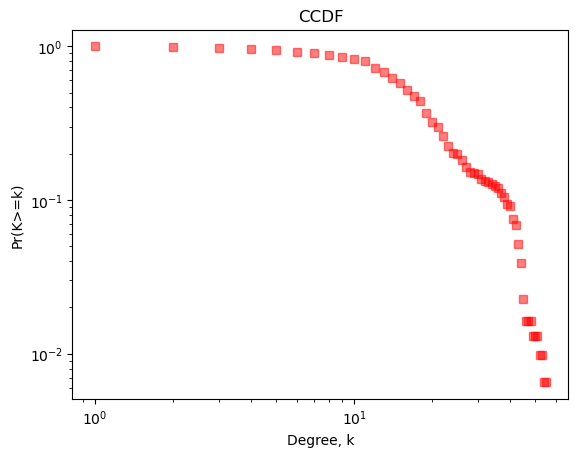

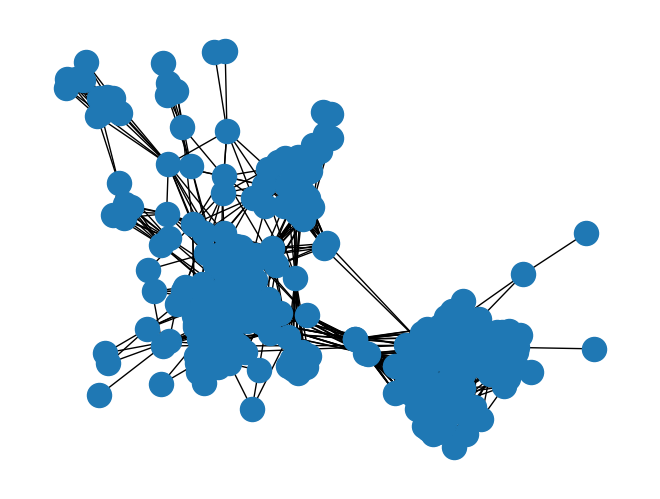

number of nodes, n  = 307
number of edges, m  = 2812
mean degree   , <k> = 18.32
clustering coefficient, C     =  0.59
mean geodesic distance, <ell> =  3.52


In [392]:
# this data set is from :
# D. B. Larremore et al., "A network approach to analyzing highly recombinant malaria parasite genes."
#                          PLOS Computational Biology 9(10), e1003268 (2013).
fname1 = 'HVR_1.txt'

# read in the network file (an edge list)
print(f'reading the network file : {fname1}\n')
G = nx.read_edgelist('./' + fname1, delimiter=',', nodetype=int)  # import as a simple graph, index nodes by integers (not strings)

####################################
##### do not modify above here #####

#Get number of nodes
n = G.number_of_nodes()
#Gets the number of edges and stores them in m
m = G.number_of_edges()
#Calculates <k> using m and n from above
kmean = 2 * m / n
#Gets transitivity of graph
C = nx.transitivity(G)
#Gets average shorest path from graph
ellmean = nx.average_shortest_path_length(G)

def plot_CCDF(kis):
    # input : a list of degrees, e.g., from a networkx graph G
    # output: a plot of the CCDF of the degree distribution Pr(K>=k) for k>=1
    
    kmax = max(kis)

    # histogram and plot
    counts, bins = np.histogram(kis, bins=[i for i in range(kmax+2)], density=True)
    cumcounts = np.cumsum(counts)
    cumcounts = np.insert(cumcounts,0,0)
    plt.loglog(bins[1:-1], 1-cumcounts[1:-1], 'rs', alpha=0.5)
    plt.xlabel('Degree, k')
    plt.ylabel('Pr(K>=k)')
    plt.title("CCDF")
    plt.show()
    return

#Builds a list of degrees
degreeList = []

for node in G:
    degree = G.degree(node)
    degreeList.append(degree)
#Plot CCDF of graph  
plot_CCDF(degreeList)

#Plot springlayout of graph
nx.draw(G, pos=nx.spring_layout(G))
plt.show()

#Print the summary stats
print(f'number of nodes, n  = {n}')
print(f'number of edges, m  = {m}')
print(f'mean degree   , <k> = %5.2f' % kmean)
print(f'clustering coefficient, C     = %5.2f' % C)
print(f'mean geodesic distance, <ell> = %5.2f' % ellmean)

### Problem 2-D (30 pts) : a good measurement, once

Now we get to play with malaria gene data. Define the edge missingness function $f$ to be one that selects a uniformly random _fraction_ $\alpha$ of edges in $G$ to observe in $G_\circ$.

Because $f$ is a stochastic function, the AUC we calculate will be a random variable, and we will need to average the AUC over several _repetitions_ to get a good estimate.

* Set `nrep=3` and $\alpha=0.8$, and let each edge $(i,j)\in G$ be observed in $G_\circ$ with probability $\alpha$.
* For each repetition, create a new $G_\circ$, apply all 3 predictors to its set of non-edges, compute and store the AUCs for each predictor
* In each repetition, write out its results like `[rep=0] baseline AUC = {a}   Jaccard AUC = {b}   degprod AUC = {c}`
* In the *first* repetition only, output a plot of the ROC curves (all on one figure) of the 3 predictors.
* Finally, briefly comment about any confirmations or surprises you see in the ROC plot or the AUC results, for each of the predictors, *and* what the relative performance of `Jaccard` vs. `degree product` says about the structure of the network. Refer back to the summary statistics you found in `2-C` to justify your comments.

Hint 1: you might be tempted to use the `.copy` functionality in `networkx` or to try a straight assignment `Go=G`. I recommend not doing this, because both are *shallow* copies. Instead, start with a new empty graph like `Go = nx.Graph()` and then iterate through `G.edges()`, using `Go.add_edges_from()` to add each observed edge one at a time.

Hint 2: you can check that your code is about right by trying a few different values of $\alpha$. When I ran it with $\alpha=0.1$, I found the Jaccard AUC $\approx0.6$, and with $\alpha=0.95$, I found degree product AUC $\approx0.7$. It makes sense that AUC should increase with $\alpha$, since at higher values, we're making fewer predictions and have more observed edges to work with.

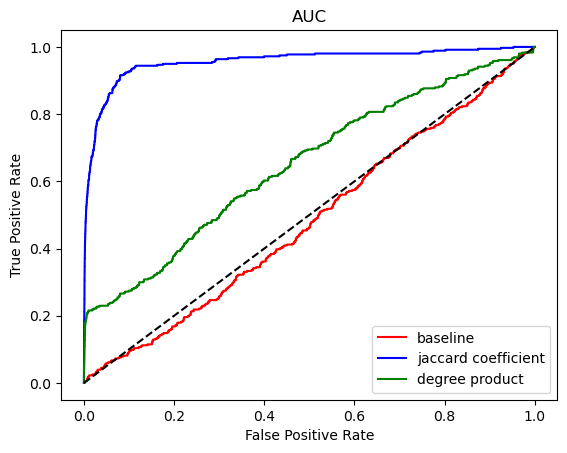

[rep=0] baseline AUC = 0.4821  Jaccard AUC = 0.9568  degprod AUC = 0.6497
[rep=1] baseline AUC = 0.4573  Jaccard AUC = 0.9589  degprod AUC = 0.6828
[rep=2] baseline AUC = 0.4949  Jaccard AUC = 0.9679  degprod AUC = 0.6517
mean baseline AUC = 0.4781 mean Jaccard AUC = 0.9612 mean degprod AUC = 0.6614


In [409]:
import random as rnd
seed = 626 # your MMYY birthday here
rnd.seed(seed)

nreps = 3     # number of repetitions to average over
alpha = 0.80  # fraction of edges to observe

AUCs_base = [] # for storing list of nreps AUCs from baseline
AUCs_jacc = [] # for storing list of nreps AUCs from jaccard
AUCs_degp = [] # for storing list of nreps AUCs from degree product

####################################
##### do not modify above here #####

def gene_missingness(G, alpha):
    # input : G, a networkx simple graph
    #         alpha, (scalar) fraction of labels to observe
    # output: Go, a network of observed edges

    #Build list of observed edges
    Eo = []
    for edge in G.edges():
        isObserved = rnd.choices([0,1], weights=[1-alpha, alpha])
        if sum(isObserved) == 1:
            Eo.append(edge)
    
    #Build graph from edge list
    Go = nx.from_edgelist(Eo)
    
    return Go


##Code to run functions
for rep in range(nreps):
    Go = gene_missingness(G, alpha)
    Y = [non_edge for non_edge in G.edges() if non_edge not in Go.edges()]
    results = apply_Predictors(Go,Y)
    
    #Takes the score table from above and grabs only elements related to baseline
    bl = results[results[:, 3].argsort()[::-1]]
    bl = np.delete(bl, 5, axis=1)
    bl = np.delete(bl, 4, axis=1)
    bl_tab = tabulate_TPR_FPR(bl)
    bl_auc = calculate_AUC(bl_tab[:, 3],bl_tab[:, 4])
    AUCs_base.append(bl_auc)
    
    #Takes the score table from above and grabs only elements related to Jaccard Coefficient
    jc = results[results[:, 4].argsort()[::-1]]
    jc = np.delete(jc, 5, axis=1)
    jc = np.delete(jc, 3, axis=1)
    jc_tab = tabulate_TPR_FPR(jc)
    jc_auc = calculate_AUC(jc_tab[:, 3],jc_tab[:, 4])
    AUCs_jacc.append(jc_auc)
    
    #Takes the score table from above and grabs only elements related to Degree Product
    dpp = results[results[:, 5].argsort()[::-1]]
    dpp = np.delete(dpp, 3, axis=1)
    dpp = np.delete(dpp, 3, axis=1)
    dpp_tab = tabulate_TPR_FPR(dpp)
    dpp_auc = calculate_AUC(dpp_tab[:, 3],dpp_tab[:, 4])
    AUCs_degp.append(dpp_auc)
    
    if rep == 0:
        #Insert 0,0 to front so graph starts at 0,0
        bl_fpr = np.insert(bl_tab[:, 4], 0, 0)
        bl_tpr = np.insert(bl_tab[:, 3], 0, 0)
        jc_fpr = np.insert(jc_tab[:, 4], 0, 0)
        jc_tpr = np.insert(jc_tab[:, 3], 0, 0)
        dpp_fpr = np.insert(dpp_tab[:, 4], 0, 0)
        dpp_tpr = np.insert(dpp_tab[:, 3], 0, 0)

        plt.plot(bl_fpr,bl_tpr, color='red', label='baseline')
        plt.plot(jc_fpr,jc_tpr, color='blue', label='jaccard coefficient')
        plt.plot(dpp_fpr,dpp_tpr, color='green', label='degree product')
        plt.plot([0,1], [0,1], color='black', linestyle='dashed' )
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("AUC")
        plt.legend(loc="lower right")
        plt.show()

    print(f"[rep={rep}] baseline AUC = {bl_auc:.4f}  Jaccard AUC = {jc_auc:.4f}  degprod AUC = {dpp_auc:.4f}")

mean_b = np.mean(AUCs_base)
mean_j = np.mean(AUCs_jacc)
mean_d = np.mean(AUCs_degp)
print(f"mean baseline AUC = {mean_b:.4f} mean Jaccard AUC = {mean_j:.4f} mean degprod AUC = {mean_d:.4f}")

Based on the graph as well as the actual AUC values, the Jaccard coefficient algorithm predicts the existence of missing links and the absence of non-missing links with an average AUC of $0.96$. In comparison the Degree product only had an average AUC of $0.66$, which is barely above the baseline. Additionally, the baseline is right around the expected random chance of guessing the absence/existence of a link, averaging an AUC of $0.48$. Looking at the results from part $2-C$ it makes sens the Jaccard Coefficient has a high rate of success with this network because the network has a decently high cluster coefficient of $c=0.69$. This means a majority of nodes exist in clusters, which the Jaccard coefficeint is better suited towards predicting links within than the degree coefficient. 

### Problem 2-E (20 pts) Putting it all together

Using the code you wrote for `Problem 2-D` as the core, now write a wrapper that allows you to perform the full numerical experiment to investigate how the 3 link predictors perform as a function of how much of the network is observed. Here, you'll conduct the experiment, record the results, and present them in a nice plot.

* Write the wrapper around your `Problem 2-D` code to measure how the mean AUC for each link predictor varies a function of $\alpha$ on the malaria gene network.

* Produce a single `plot` showing all 3 functions, for $\alpha=\{0.1, 0.3, 0.5, 0.7, 0.9\}$ and `nreps=5` (try a smaller number to see how much roughness you're smoothing over).
* (*Extra credit 5pts*: use at least 10 evenly-spaced increments of $\alpha$ between 0 and 1.)

* Then, briefly discuss what you see about how the AUC varies by link predictor with $\alpha$. What trends do you see? Do they go in the direction you would expect? Does anything interesting happen at intermediate values of $\alpha$? Try to give some intuition as to why this behavior makes sense given what we know about what structures each link predictor exploits, the structural patterns revealed by the summary statistics you calculated in `Problem 2-C`, and what effect different values of $\alpha$ have on $G_\circ$.

Hint: As in PS4, a key part of such a numerical experiment is storing the intermediate results. For each choice of $\alpha$, the core code from `Problem 2-D` will produce three AUCs; I stored these, along with $\alpha$, in a single 4-column numpy array. It was then straightforward to plot each of columns 2,3,4 vs. column 1 to make the target plot. As in PS4, I also found it useful to separate the code for the experiment from the code for the visualization, so that I could tinker with the latter without having to re-run the former. On my laptop, it took less than 2 minutes for 5 repetitions, per value of $\alpha$.

In [411]:
# YOUR SIMULATION CODE HERE
def simulation_AUC(G, nreps, alpha):
    AUCs_base = [] # for storing list of nreps AUCs from baseline
    AUCs_jacc = [] # for storing list of nreps AUCs from jaccard
    AUCs_degp = [] # for storing list of nreps AUCs from degree product

    for rep in range(nreps):
        Go = gene_missingness(G, alpha)
        Y = [non_edge for non_edge in G.edges() if non_edge not in Go.edges()]
        results = apply_Predictors(Go,Y)

        #Takes the score table from above and grabs only elements related to baseline
        bl = results[results[:, 3].argsort()[::-1]]
        bl = np.delete(bl, 5, axis=1)
        bl = np.delete(bl, 4, axis=1)
        bl_tab = tabulate_TPR_FPR(bl)
        bl_auc = calculate_AUC(bl_tab[:, 3],bl_tab[:, 4])
        AUCs_base.append(bl_auc)

        #Takes the score table from above and grabs only elements related to Jaccard Coefficient
        jc = results[results[:, 4].argsort()[::-1]]
        jc = np.delete(jc, 5, axis=1)
        jc = np.delete(jc, 3, axis=1)
        jc_tab = tabulate_TPR_FPR(jc)
        jc_auc = calculate_AUC(jc_tab[:, 3],jc_tab[:, 4])
        AUCs_jacc.append(jc_auc)

        #Takes the score table from above and grabs only elements related to Degree Product
        dpp = results[results[:, 5].argsort()[::-1]]
        dpp = np.delete(dpp, 3, axis=1)
        dpp = np.delete(dpp, 3, axis=1)
        dpp_tab = tabulate_TPR_FPR(dpp)
        dpp_auc = calculate_AUC(dpp_tab[:, 3],dpp_tab[:, 4])
        AUCs_degp.append(dpp_auc)

    mean_b = np.mean(AUCs_base)
    mean_j = np.mean(AUCs_jacc)
    mean_d = np.mean(AUCs_degp)

    print(f"mean baseline AUC = {mean_b:.4f} mean Jaccard AUC = {mean_j:.4f} mean degprod AUC = {mean_d:.4f}")
    return mean_b, mean_j, mean_d

#Initial Vars
nreps = 5
alphaList = [0.1,0.3,0.5,0.7,0.9]
#alphaList = [0.05,0.15,0.25,0.35,0.45,0.55,0.65,0.75,0.85,0.95]

AUCs_base_vs_a = []
AUCs_jacc_vs_a = []
AUCs_degp_vs_a = []

for alpha in alphaList:
    mean_b, mean_j, mean_d = simulation_AUC(G, nreps, alpha)
    AUCs_base_vs_a.append(mean_b)
    AUCs_jacc_vs_a.append(mean_j)
    AUCs_degp_vs_a.append(mean_d)

mean baseline AUC = 0.4984 mean Jaccard AUC = 0.5807 mean degprod AUC = 0.6005
mean baseline AUC = 0.5079 mean Jaccard AUC = 0.7862 mean degprod AUC = 0.6403
mean baseline AUC = 0.4990 mean Jaccard AUC = 0.8989 mean degprod AUC = 0.6568
mean baseline AUC = 0.4946 mean Jaccard AUC = 0.9470 mean degprod AUC = 0.6631
mean baseline AUC = 0.5047 mean Jaccard AUC = 0.9742 mean degprod AUC = 0.6609


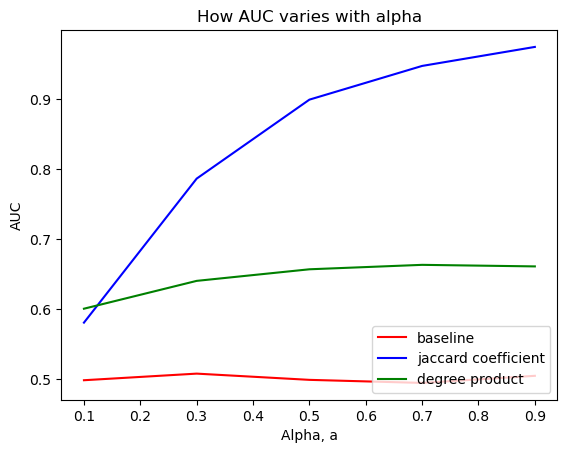

In [413]:
# YOUR PLOTTING CODE HERE (so your simulation doesn't need to re-run just to tinker with how the plots look)

plt.plot(alphaList,AUCs_base_vs_a, color='red', label='baseline')
plt.plot(alphaList,AUCs_jacc_vs_a, color='blue', label='jaccard coefficient')
plt.plot(alphaList,AUCs_degp_vs_a, color='green', label='degree product')
plt.xlabel("Alpha, a")
plt.ylabel("AUC")
plt.title("How AUC varies with alpha")
plt.legend(loc="lower right")
plt.show()

This graph clearly shows how as the alpha increases the AUC of the Jaccard Coefficient and Degree Product increase(although not at similar rates), which makes sense because as the number of observed edges increase logically the predictions will become more accurate as they have more data to work with. Additionally, the baseline remains the pretty much the same, which is expected because it does not account for changes in the observed data. 

It is likely the AUC of the Jaccard coefficient increases more rapidly than AUC of the Degree product because, as mentioned before, this network appears to have a higher clustering coefficient which the Jaccard Coefficient predicts more accurately. Even when almost all the edges are observed the degree product still has a relatively low AUC, which may be do to a high variance in the degrees between each node making it difficult for the degree product to predict if an edge exists or not(or it may be a mistake in the code).

***
***

## Problem 3 : Reading the literature (*10 pts extra credit*)

Choose a paper from the [Supplemental Reading list on the external course webpage](https://aaronclauset.github.io/courses/3352/). Read the paper (the whole paper, not just the abstract). Think about what it says. Then, write 1-3 sentences for each of the following questions in a way that clearly summarizes the work, and its context.
* What was the research question?
* What was the approach the authors took to answer that question?
* What did they do well?
* What could they have done better?
* What extensions can you envision?


Do not copy any text from the paper itself; write your own summary, in your own words in Markdown in the corresponding box below. Be sure to answer each of the five questions. The amount of extra credit will depend on the accuracy and thoughtfulness of your answers.

Hint: This is a good way to generate some ideas for your class project (your proposal for that is due on **February 27th**. Also, even if you don't understand everything in the paper, that's okay. Do your best to summarize what you did understand.

* *What paper did you choose?*<br/>
Give the Authors, Title, Publication Venue, Year
<br/>

* *What was the research question?*<br/>
Your answer here
<br/>

* *What was the approach the authors took to answer that question?*<br/>
Your answer here
<br/>

* *What did they do well?*<br/>
Your answer here
<br/>

* *What could they have done better?*<br/>
Your answer here
<br/>

* *What extensions can you envision?*<br/>
Your answer here

***
***

## Problem 4 : Netwulf (*10 pts extra credit*)

Recently, Ulf Aslak and Benjamin F. Maier published a paper entitled "[Netwulf: Interactive visualization of networks in Python](https://joss.theoj.org/papers/10.21105/joss.01425)" in the *Journal of Open Source Software* that describes a python package called `netwulf` for creating network visualizations inside Jupyter notebooks. I haven't had a chance to try it out, but since we all know that the visualization options in `networkx` are pretty poor, it seems like a promising thing to add to this course.

For this question, write a small tutorial below that could be made available as a standalone Jupyter notebook to future students of `CSCI 3352 Biological Networks` that 
* explains how to install the package ([github page here](http://github.com/benmaier/netwulf))
* steps through creating a visualization using a toy (very small, stylized) network
* explains the adjustment of relevant parameters (be sure to explain which parameters to adjust, and why), and 
* illustrates both (i) exporting the image as a PNG and (ii) plotting it within a notebook
* then, use `netwulf` to create a visualization of one of the network data sets we've seen in class so far.

Hint: Imagine what kind of a tutorial *you* would have liked to have read in weeks 1-2 of this course, and then write that tutorial.